# 3. Fuzzy sets, rules and partitions from the ground up

The classifiers hide the machinery. This notebook builds it by hand so the
printed rules, the plots and the constructor options make sense: fuzzy
sets, fuzzy variables, rules and rule bases, fixed versus optimised
partitions, Type-2 sets, inference modes, and saving models as text.

In [1]:
import tempfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from ex_fuzzy import BaseFuzzyRulesClassifier, eval_rules, fuzzy_sets as fs, persistence, rules, utils, vis_rules

## Fuzzy sets and fuzzy variables

A Type-1 fuzzy set `FS` has a name, four trapezoid parameters and a domain.
A `fuzzyVariable` groups the sets that describe one input; its
`compute_memberships` returns the degree of every set for every value.

In [2]:
cold = fs.FS('cold', [0, 0, 5, 15], [0, 40])
warm = fs.FS('warm', [10, 18, 22, 30], [0, 40])
hot = fs.FS('hot', [25, 32, 40, 40], [0, 40])
temperature = fs.fuzzyVariable('temperature', [cold, warm, hot], units='degrees')

readings = np.array([2.0, 12.0, 20.0, 27.0, 36.0])
pd.DataFrame(temperature.compute_memberships(readings), index=temperature.linguistic_variable_names(), columns=readings).round(2)

,2.0,12.0,20.0,27.0,36.0
cold,1.0,0.30,0.0,0.00,0.0
warm,0.0,0.25,1.0,0.38,0.0
hot,0.0,0.00,0.0,0.29,1.0


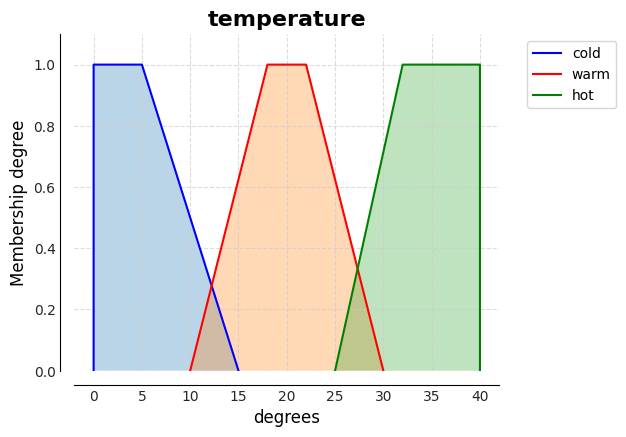

In [3]:
vis_rules.plot_fuzzy_variable(temperature)

An interval Type-2 set (`IVFS`) has a lower and an upper membership
function, so every membership is an interval; it models uncertainty about
the membership itself. The rule bases handle both kinds the same way.

memberships at 20 degrees, [lower, upper]: [[0.85 1.  ]]


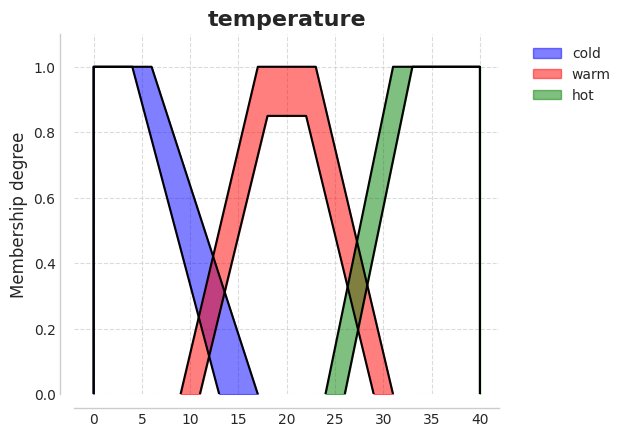

In [4]:
warm_iv = fs.IVFS('warm', [11, 18, 22, 29], [9, 17, 23, 31], [0, 40], lower_height=0.85)
print('memberships at 20 degrees, [lower, upper]:', warm_iv.membership(np.array([20.0])).round(2))
vis_rules.plot_fuzzy_variable(fs.fuzzyVariable('temperature', [
    fs.IVFS('cold', [0, 0, 4, 13], [0, 0, 6, 17], [0, 40]), warm_iv, fs.IVFS('hot', [26, 33, 40, 40], [24, 31, 40, 40], [0, 40])]))

## Rules and rule bases by hand

A `RuleSimple` lists, per input variable, the index of the fuzzy set it
uses, with -1 for variables it ignores. Classification uses one `RuleBase`
per class, gathered in a `MasterRuleBase`. Let's write the Iris rules a
botanist would write and see how well they do.

In [5]:
iris = load_iris(as_frame=True)
X = iris.frame.drop(columns='target')
y = iris.target_names[iris.target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, stratify=y)

partitions = utils.construct_partitions(X_train, fs.FUZZY_SETS.t1)   # three sets per variable: Low, Medium, High
print([variable.name for variable in partitions])

setosa = rules.RuleBaseT1(partitions, [rules.RuleSimple([-1, -1, 0, -1])])                   # petal length IS Low
versicolor = rules.RuleBaseT1(partitions, [rules.RuleSimple([-1, -1, 1, 1])])                # petal length AND width Medium
virginica = rules.RuleBaseT1(partitions, [rules.RuleSimple([-1, -1, 2, -1]),                 # petal length IS High
                                          rules.RuleSimple([-1, -1, -1, 2])])                # petal width IS High
handmade = rules.MasterRuleBase([setosa, versicolor, virginica], consequent_names=list(iris.target_names))

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Rules need their dominance scores before they can vote. `evalRuleBase`
computes them on training data, together with per-rule accuracies.

In [6]:
evaluator = eval_rules.evalRuleBase(handmade, X_train.to_numpy(), y_train)
evaluator.add_full_evaluation()
handmade.print_rules()
predicted = handmade.winning_rule_predict(X_test.to_numpy(), out_class_names=True)
print(f'handmade rules, test accuracy: {np.mean(predicted == y_test):.3f}')

Rules for consequent: setosa
----------------
IF petal length (cm) IS Low WITH DS 0.3136333333333334, ACC 1.0

Rules for consequent: versicolor
----------------
IF petal length (cm) IS Medium AND petal width (cm) IS Medium WITH DS 0.26721362136051796, ACC 0.96875

Rules for consequent: virginica
----------------
IF petal length (cm) IS High WITH DS 0.25623638344226574, ACC 0.8571428571428571
IF petal width (cm) IS High WITH DS 0.2830081300813008, ACC 0.9642857142857143


handmade rules, test accuracy: 0.980


## Fixed versus optimised partitions

With `linguistic_variables` given, the search only chooses rules. Without
them, it also moves the trapezoids of every variable. Optimised partitions
can fit better but cost more per candidate and produce sets that no longer
align with the data quantiles, so read them with the plots.

In [7]:
results = []
fixed = BaseFuzzyRulesClassifier(nRules=10, nAnts=3, linguistic_variables=partitions, n_gen=30, pop_size=30, random_state=0)
optimised = BaseFuzzyRulesClassifier(nRules=10, nAnts=3, n_linguistic_variables=3, n_gen=30, pop_size=30, random_state=0)
for name, model in (('fixed', fixed), ('optimised', optimised)):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    results.append({'partitions': name, 'fit seconds': round(time.perf_counter() - start, 1),
                    'test accuracy': round(model.score(X_test, y_test), 3), 'rules': len(model.rule_base.get_rules())})
pd.DataFrame(results)

,partitions,fit seconds,test accuracy,rules
0,fixed,0.1,0.80,3
1,optimised,0.4,0.86,3


Rules for consequent: setosa
----------------
IF sepal length (cm) IS Medium AND sepal width (cm) IS Low AND petal length (cm) IS High WITH DS 0.0, ACC 1.0

Rules for consequent: versicolor
----------------
IF sepal length (cm) IS Medium AND petal length (cm) IS Medium WITH DS 0.18373877063468, ACC 0.7857142857142857

Rules for consequent: virginica
----------------
IF petal length (cm) IS High WITH DS 0.18987647658907153, ACC 1.0




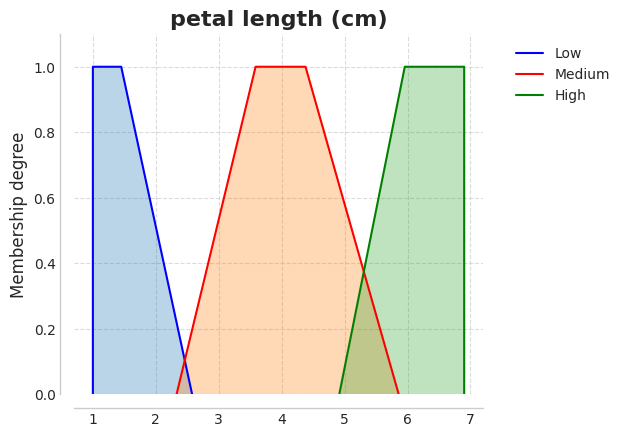

In [8]:
optimised.rename_fuzzy_variables()          # name the optimised sets Low/Medium/High by position
vis_rules.plot_fuzzy_variable(optimised.lvs[2])
optimised.print_rules()

## Type-2 partitions

`construct_partitions` builds interval Type-2 partitions on request, and
`BaseFuzzyRulesClassifier` accepts them unchanged. Rule statistics become
intervals and are reported by their mean.

Type-2 test accuracy: 0.960


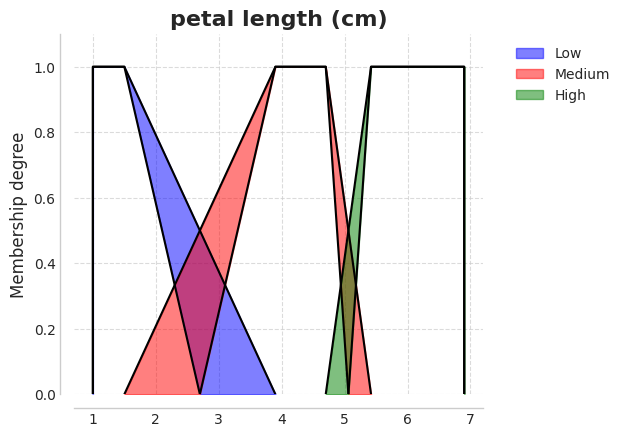

In [9]:
partitions_t2 = utils.construct_partitions(X_train, fs.FUZZY_SETS.t2)
vis_rules.plot_fuzzy_variable(partitions_t2[2])
type2 = BaseFuzzyRulesClassifier(nRules=10, nAnts=3, linguistic_variables=partitions_t2, n_gen=30, pop_size=30, random_state=0)
type2.fit(X_train, y_train)
print(f'Type-2 test accuracy: {type2.score(X_test, y_test):.3f}')

## Validating partitions

`validate_partitions` checks that each variable's sets cover the whole
range, peak one at a time, are ordered, and induce statistically different
memberships. Optimised partitions can violate these, which is the price of
their flexibility.

In [10]:
print('fixed:    ', utils.validate_partitions(X_train, partitions))
print('optimised:', utils.validate_partitions(X_train, optimised.lvs, verbose=True))

fixed:     [True, True, True, True]
Validating fuzzy variable sepal length (cm)...
Fuzzy variable sepal length (cm) is valid.
Validating fuzzy variable sepal width (cm)...
Fuzzy variable sepal width (cm) is valid.
Validating fuzzy variable petal length (cm)...


Fuzzy variable petal length (cm) is valid.
Validating fuzzy variable petal width (cm)...
Fuzzy variable petal width (cm) is valid.
optimised: [True, True, True, True]


## Inference modes

A sample is assigned to the rule with the largest association degree.
`ds_mode` decides how the firing strength is weighted: by the dominance
score (`'dominance'`, the default), not at all (`'unweighted'`), or by a
weight per rule that the genetic search optimises (`'optimized'`). With
`allow_unknown=True`, samples that fire no rule get the label -1 (or
'Unknown') instead of a guess.

In [11]:
rows = []
for mode in ('dominance', 'unweighted', 'optimized'):
    model = BaseFuzzyRulesClassifier(nRules=10, nAnts=3, linguistic_variables=partitions, ds_mode=mode,
                                     n_gen=30, pop_size=30, random_state=0).fit(X_train, y_train)
    rows.append({'ds_mode': mode, 'test accuracy': round(model.score(X_test, y_test), 3), 'rules': len(model.rule_base.get_rules())})
pd.DataFrame(rows)

,ds_mode,test accuracy,rules
0,dominance,0.80,3
1,unweighted,0.70,3
2,optimized,0.94,4


## Rules as tables and LaTeX

In [12]:
vis_rules.filter_useless_columns(vis_rules.matrix_rule_base_form(fixed.rule_base[0]))   # class 0, label indexes per variable

,sepal length (cm),petal width (cm)
0,1.0,2.0


In [13]:
latex = vis_rules.rules_to_latex(fixed.rule_base)

\begin{tabular}{ccccc|cc}
	\toprule
	Consequent & sepal length (cm) & sepal width (cm) & petal length (cm) & petal width (cm) & DS & Acc \\
	\midrule
	\multirow{1}{*}{0.0} & \cellcolor{gray!25}\med & \cellcolor{gray!25}\dc & \cellcolor{gray!25}\dc & \cellcolor{gray!25}\hig & \cellcolor{gray!25}\low & \cellcolor{gray!25}0.72 \\
	\midrule
	\multirow{1}{*}{1.0} & \dc & \low & \dc & \dc & 0.10 & 0.90 \\
	\midrule
	\multirow{1}{*}{2.0} & \cellcolor{gray!25}\dc & \cellcolor{gray!25}\dc & \cellcolor{gray!25}\dc & \cellcolor{gray!25}\hig & \cellcolor{gray!25}0.28 & \cellcolor{gray!25}0.94 \\
	\bottomrule
\end{tabular}


## Saving and loading as text

Partitions and rules serialise to plain text, the same text `print_rules`
shows. A classifier can be rebuilt from the loaded rules without
retraining.

In [14]:
folder = Path(tempfile.mkdtemp())
(folder / 'partitions.txt').write_text(persistence.save_fuzzy_variables(fixed.lvs))
(folder / 'rules.txt').write_text(fixed.print_rules(return_rules=True))
print((folder / 'partitions.txt').read_text()[:260], '...')

loaded_partitions = persistence.load_fuzzy_variables((folder / 'partitions.txt').read_text())
loaded_rules = persistence.load_fuzzy_rules((folder / 'rules.txt').read_text(), loaded_partitions)
restored = BaseFuzzyRulesClassifier(precomputed_rules=loaded_rules)
agreement = np.mean(restored.predict(X_test, out_class_names=True) == fixed.predict(X_test))
print(f'restored model agrees with the original on {agreement:.0%} of the test samples')

$$$ Linguistic variable: sepal length (cm)
Low;4.3,7.9;trap;4.2999,4.2999,5.0,5.6
Medium;4.3,7.9;trap;5.0,5.6,6.1,6.6
High;4.3,7.9;trap;6.1,6.6,7.9001,7.9001

$$$ Linguistic variable: sepal width (cm)
Low;2.0,4.4;trap;1.9999,1.9999,2.7,2.9
Medium;2.0,4.4;trap; ...
restored model agrees with the original on 100% of the test samples
